In [1]:
import pandas as pd
import numpy as np
from datatools import get_index_K, get_price, get_cyq, get_rzrq, get_moneyflow, get_technical,strategy_metrics
import lightgbm as lgb
import matplotlib.pyplot as plt
from cal_cne6_factor import calc_cne6_factors

### 取特征及样本

In [2]:
allstock = pd.read_csv('C:/Users/User/OneDrive - CUHK-Shenzhen/data/allstock.csv')
allstock_list = allstock[(allstock['list_date'] < 20260101) & ~allstock['ts_code'].str.contains('BJ')].ts_code.tolist()
start_date = '2019-01-01'
end_date = '2026-03-31'

In [3]:
all_sample = get_price(allstock_list, '2019-01-01', '2026-05-31',fields=['open'])
all_sample['1d_return'] = all_sample.groupby('ts_code')['open'].shift(-1) / all_sample['open'] - 1
all_sample.rename(columns={'open':'next_open'}, inplace=True)
all_sample = all_sample.fillna(-0.9999999)
all_sample['trade_date'] = all_sample.groupby('ts_code')['trade_date'].shift(1)
all_sample = all_sample[all_sample.trade_date.between(start_date, end_date)]

In [4]:
all_sample['1d_excess_returns'] = all_sample['1d_return'] - all_sample.groupby('trade_date')['1d_return'].transform('mean')
all_sample['Y_1d'] = all_sample.groupby('trade_date')['1d_excess_returns'].rank(pct=True)

In [9]:
all_sample.to_parquet('data/factor/all_sample.parquet', index=False)

In [ ]:
factor1 = calc_cne6_factors(allstock_list, '2019-01-01', '2026-03-31')

cyq = get_cyq(allstock_list, '2019-01-01', '2026-03-31')
rzrq = get_rzrq(allstock_list, '2019-01-01', '2026-03-31')
monthflow = get_moneyflow(allstock_list, '2019-01-01', '2026-03-31')

tech = get_technical(allstock_list, '2019-01-01', '2026-03-31')

加载价格数据...
加载指数数据...
矩阵: 2019 交易日 × 221 只股票
计算 Daily std...
计算 Cumulative range...


c:\Users\User\Desktop\Quant\cal_cne6_factor.py:99: RuntimeWarning: All-NaN slice encountered
  factor_values = np.nanmax(window_rets, axis=0) - np.nanmin(window_rets, axis=0)


计算 Short Term reversal...
计算 Seasonality...
计算 Industry Momentum...
计算 BETA / Hist sigma / Historical alpha...
计算 Relative strength...
加载长期价格数据...
加载长期指数数据...
计算 Long term relative strength...
计算 Long term historical alpha...
加载基础数据...
加载财务数据...
加载TTM数据...
计算换手率因子...
计算市值因子...
计算估值/杠杆因子...
计算盈利能力...
计算财务质量因子...
计算应计项目...
计算投资质量...
加载分析师预测数据...
计算分析师预测因子...
组装结果...
done


In [ ]:
factor1.to_parquet('data/factor/cne6_factor.parquet', index=False)
factor2 = pd.merge(cyq, rzrq, on=['trade_date', 'ts_code'], how='outer').merge(monthflow, on=['trade_date', 'ts_code'], how='outer')
factor2.to_parquet('data/factor/other_factor.parquet', index=False)
tech.to_parquet('data/factor/tech_factor.parquet', index=False)

### 特征预处理

In [27]:
all_sample = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/all_sample.parquet')
factor1 = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/cne6_factor.parquet')
factor2 = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/other_factor.parquet')
factor3 = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/tech_factor.parquet')

In [ ]:
factor = all_sample.merge(factor1, on=['ts_code', 'trade_date'], how='left').merge(
    factor2, on=['ts_code', 'trade_date'], how='left').merge(factor3, on=['ts_code', 'trade_date'], how='left')

In [ ]:
ind = pd.read_csv('C:/Users/User/OneDrive - CUHK-Shenzhen/data/industry.csv')
factor = factor.merge(ind[['ts_code', 'l1_name']], on='ts_code', how='left')
factor = pd.get_dummies(factor, columns=['l1_name'], drop_first=True, dtype=int)

def neutralize_date(group):
    X_raw = group[factor.columns[-30:].tolist() + ['lncap']].values
    X = np.column_stack((np.ones(X_raw.shape[0]), X_raw))
    # 预分配残差矩阵，默认全为 NaN
    resid_matrix = np.full((group.shape[0], 155), np.nan)
    # 2. 必须按列独立回归，处理各自的缺失值
    for j, col in enumerate(factor.columns[8:-30]):
        try:
            median = group[col].median()
            mad = (group[col] - median).abs().median()
            group[col] = group[col].clip(median - 5 * mad, median + 5 * mad)
            mean = group[col].mean()
            std = group[col].std()
            if std == 0:
                group[col] = np.nan  # 波动为0的因子无信息，置0
            else:
                group[col] = (group[col] - mean) / std
            
            Y_raw = group[col].values
            # 核心：只判断当前因子列的缺失值
            valid_idx = ~np.isnan(Y_raw) & np.all(~np.isnan(X), axis=1)
            X_valid = X[valid_idx]
            Y_valid = Y_raw[valid_idx]
            # 3. 底层 NumPy 最小二乘法求解
            beta, _, _, _ = np.linalg.lstsq(X_valid, Y_valid[:, np.newaxis])
            # 计算残差并展平为一维
            resid_valid = Y_valid - (X_valid @ beta).flatten()
            # 4. 只将有效行的残差填入对应位置，无效行保持 NaN
            resid_matrix[valid_idx, j] = resid_valid
        except:
            print(group.name, col)
    # 5. 映射回 DataFrame
    group[factor.columns[8:-30]] = resid_matrix
    return group
factor =  factor.groupby('trade_date').apply(neutralize_date).reset_index(level=0)
factor = factor.drop(columns=factor.columns[-30:].tolist() + ['lncap'])

In [ ]:
factor.to_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/sample_train_oot.parquet', index=False)

#### training

In [ ]:
sample_train_oot = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/sample_train_oot.parquet').drop(
    columns=['adj_factor', '20d_returns','bench_20d_return', '20d_excess_returns', 'Y_20d'])

sample_train_oot = sample_train_oot.merge(all_sample[['ts_code', 'trade_date', '1d_return', '1d_excess_returns',
       'Y_1d']], on=['trade_date', 'ts_code'], how='inner')

In [ ]:
# index_weight = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/index/index_weight/index_weight-000300.SH.parquet')
# index_weight.trade_date = pd.to_datetime(index_weight.trade_date)
# index_weight = index_weight.rename(columns={'con_code':'ts_code'})
# monthly_stocks = index_weight.groupby('trade_date')['ts_code'].apply(set).reset_index()
# monthly_stocks['prev_stocks'] = monthly_stocks['ts_code'].shift(1)
# # 3. 定义函数计算差异（新增数、剔除数、总变动数）
# def calc_changes(row):
#     if pd.isna(row['prev_stocks']):
#         return pd.Series({'add': 0, 'remove': 0, 'total_changed': 0})
#     curr_stocks = row['ts_code']
#     prev_stocks = row['prev_stocks']
#     # 本月有但上月没有的（新增/调入）
#     added = len(curr_stocks - prev_stocks)
#     # 上月有但本月没有的（剔除/调出）
#     removed = len(prev_stocks - curr_stocks)
#     # 总变动数量 = 新增 + 剔除
#     total_changed = added + removed
#     return pd.Series({'add': added, 'remove': removed, 'total_changed': total_changed})
# # 4. 应用计算并输出结果
# changes = monthly_stocks.apply(calc_changes, axis=1)
# result = pd.concat([monthly_stocks[['trade_date']], changes], axis=1)
# index_weight = index_weight[index_weight.trade_date.isin(set(result.query('total_changed>0').trade_date))]

In [ ]:
sample_train = sample_train_oot[sample_train_oot['trade_date'] < '2025-01-01']

In [9]:
# 从 train_val_df 中切出 20% 作为验证集
val_df = sample_train[sample_train['trade_date'] >= '2024-01-01']
train_df = sample_train[sample_train['trade_date'] < '2024-01-01']
feature_cols = sample_train.columns[3:-4]
lgb_train = lgb.Dataset(train_df[feature_cols], train_df['Y_1d'])
lgb_val = lgb.Dataset(val_df[feature_cols], val_df['Y_1d'])

In [10]:

lgb_params = {
    'objective': 'regression', 
    'metric': 'rmse', 
    'learning_rate': 0.03,     
    'max_depth': 4,            
    'num_leaves': 10,          
    'subsample': 0.7,          
    'colsample_bytree': 0.6,   
    'reg_alpha': 0.5,          
    'reg_lambda': 1.0,         
    'min_child_samples': 200,  
    'n_estimators': 1000,      
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# 3. 训练模型
model = lgb.train(
    lgb_params,
    lgb_train,
    valid_sets=[lgb_val],
    callbacks=[lgb.early_stopping(10), lgb.log_evaluation(10)])

sample_train_oot['predict_score'] = model.predict(sample_train_oot[feature_cols])

Training until validation scores don't improve for 10 rounds
[10]	valid_0's rmse: 0.288409
[20]	valid_0's rmse: 0.288246
[30]	valid_0's rmse: 0.28814
[40]	valid_0's rmse: 0.288066
[50]	valid_0's rmse: 0.288006
[60]	valid_0's rmse: 0.28796
[70]	valid_0's rmse: 0.287922
[80]	valid_0's rmse: 0.287893
[90]	valid_0's rmse: 0.287864
[100]	valid_0's rmse: 0.287842
[110]	valid_0's rmse: 0.287828
[120]	valid_0's rmse: 0.287816
[130]	valid_0's rmse: 0.287807
[140]	valid_0's rmse: 0.287796
[150]	valid_0's rmse: 0.287787
[160]	valid_0's rmse: 0.287779
[170]	valid_0's rmse: 0.28777
[180]	valid_0's rmse: 0.287759
[190]	valid_0's rmse: 0.287754
[200]	valid_0's rmse: 0.287746
[210]	valid_0's rmse: 0.28774
[220]	valid_0's rmse: 0.287733
[230]	valid_0's rmse: 0.287727
[240]	valid_0's rmse: 0.287723
[250]	valid_0's rmse: 0.287719
[260]	valid_0's rmse: 0.287714
[270]	valid_0's rmse: 0.28771
[280]	valid_0's rmse: 0.287706
[290]	valid_0's rmse: 0.2877
[300]	valid_0's rmse: 0.287697
[310]	valid_0's rmse: 0.2

In [11]:
feat_imp_df = pd.DataFrame({'feature': model.feature_name(), 'gain': model.feature_importance(importance_type='gain')})
feat_imp_df['gain'] /= feat_imp_df['gain'].sum()
feat_imp_df = feat_imp_df.sort_values(by='gain', ascending=False)
print("Top 10 Features by Gain:")
print(feat_imp_df.head(10))

Top 10 Features by Gain:
           feature      gain
61  sell_md_amount  0.109687
84       bias1_hfq  0.109099
67  buy_elg_amount  0.080403
86       bias3_hfq  0.058738
57  sell_sm_amount  0.054712
0        daily_std  0.048301
85       bias2_hfq  0.038577
6       hist_sigma  0.030728
71   net_mf_amount  0.028961
12            stom  0.023821


### step 4

In [ ]:
# sample_oot : DataFrame, 包含 'trade_date', 'ts_code','daily_return' 列
# trade_records : DataFrame, 交易记录, 包含 'ts_code', 'buy_date', 'buy_price', 'sell_date', 'sell_price' 列

In [12]:
sample_oot = sample_train_oot[(sample_train_oot['trade_date'] >= '2023-01-01')]

In [13]:
sample_oot['sell_price'] = sample_oot.groupby('ts_code')['next_open'].shift(-1)
sample_oot['sell_date'] = sample_oot.groupby('ts_code')['trade_date'].shift(-1)

In [14]:
# unique_dates = sample_oot['trade_date'].drop_duplicates().sort_values().reset_index(drop=True)
# signal_dates = set(unique_dates[(unique_dates.index) % 20 == 0])
# signal_df = sample_oot[sample_oot['trade_date'].isin(signal_dates)]
trade_records = sample_oot[sample_oot.groupby('trade_date')['predict_score'].rank(method='first', pct=True) > 0.9]
trade_records = trade_records[['ts_code', 'trade_date', 'next_open', 'sell_date', 'sell_price']].rename(columns={'trade_date': 'buy_date', 'next_open': 'buy_price'})
trade_records = trade_records[trade_records.sell_date.notna()]

In [ ]:
# index_weight = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/index/index_weight/index_weight-000300.SH.parquet')
# date_mapping = pd.merge_asof(trade_records[['buy_date']].drop_duplicates(), 
#                              index_weight[['trade_date']].drop_duplicates(), 
#                              left_on='buy_date', right_on='trade_date', direction='backward')
# trade_records = trade_records.merge(date_mapping, on='buy_date',how='left').merge(
#                                 index_weight, on=['trade_date', 'ts_code'], how='inner')

In [31]:
metrics, df_res = strategy_metrics(sample_oot[['trade_date', 'ts_code','daily_return']], trade_records,  cost=0)

UnboundLocalError: cannot access local variable 'benchmark' where it is not associated with a value

In [ ]:
metrics

{'sharpe_ratio': np.float64(1.4324490449712055),
 'max_drawdown': np.float64(-0.3595687514278061),
 'win_rate': np.float64(0.50274973859889)}

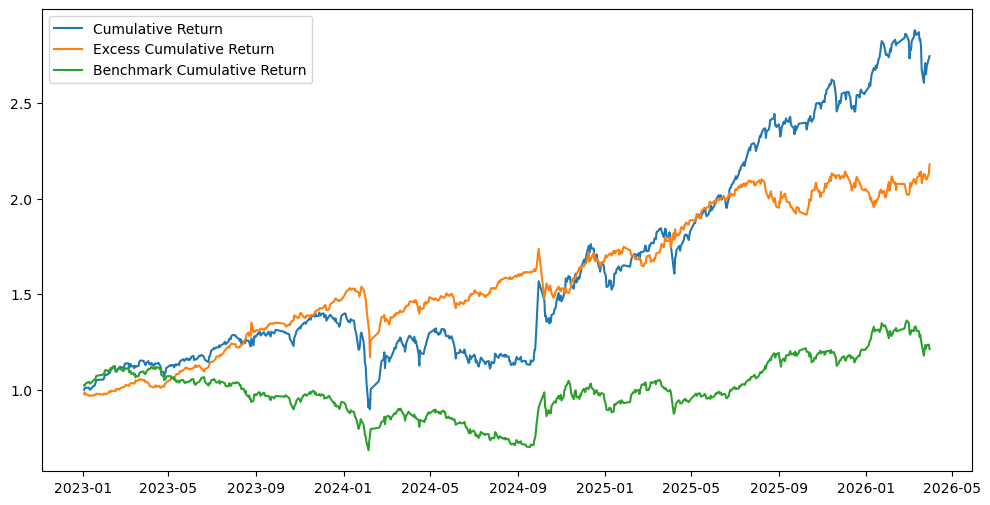

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_res['trade_date'], df_res['cum_nav'], label='Cumulative Return')
plt.plot(df_res['trade_date'], df_res['cum_excess_nav'], label='Excess Cumulative Return')
plt.plot(df_res['trade_date'], df_res['cum_bench_nav'], label='Benchmark Cumulative Return')
plt.legend()
plt.show()